In [9]:
import numpy as np 
import pandas as pd 

import datetime as dt
from datetime import datetime

import investpy as ipy

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt 
import seaborn as sns
plt.style.use('ggplot')
%matplotlib inline

In [41]:
now = datetime.now()
today = now.strftime('%d/%m/%Y')

eth = ipy.get_crypto_historical_data(crypto='ethereum', from_date = '01/01/2019', to_date = today)
eth.head()

,Open,High,Low,Close,Volume,Currency
Date,,,,,,
2019-01-01,131.90,140.51,130.67,139.61,3053350,USD
2019-01-02,139.58,155.93,138.74,152.95,5511607,USD
2019-01-03,152.96,154.30,144.39,146.94,4018093,USD
2019-01-04,146.94,155.40,145.29,152.86,4923992,USD
2019-01-05,152.87,159.78,152.84,153.49,4847379,USD


In [44]:
eth_rets = np.log(1+btc['Close'].pct_change())
mu = btc_rets.mean()
sigma = btc_rets.std()
sim_rets = np.random.normal(mu, sigma, 365) #random value of normal distribution with mean and std as the parameters
                                 # impute int for days into the futre
eth_latest_price = eth['Close'].iloc[-1] # get last closing price
eth_simulation_365_days_from_now = eth_latest_price * (sim_rets + 1).cumprod() #get the cumulative returns

Text(0.5, 1.0, 'Ethereum Monte Carlo Simulation')

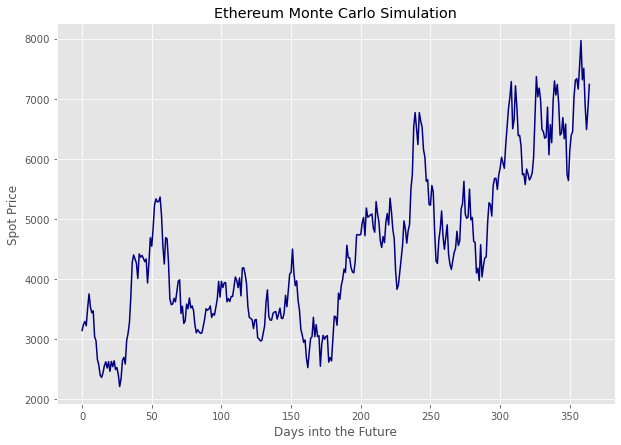

In [45]:
f, ax = plt.subplots(figsize=(10,7)) # one simulation

ax.plot(eth_simulation_365_days_from_now, color = 'navy')
ax.set_xlabel('Days into the Future')
ax.set_ylabel('Spot Price')
ax.set_title('Ethereum Monte Carlo Simulation')

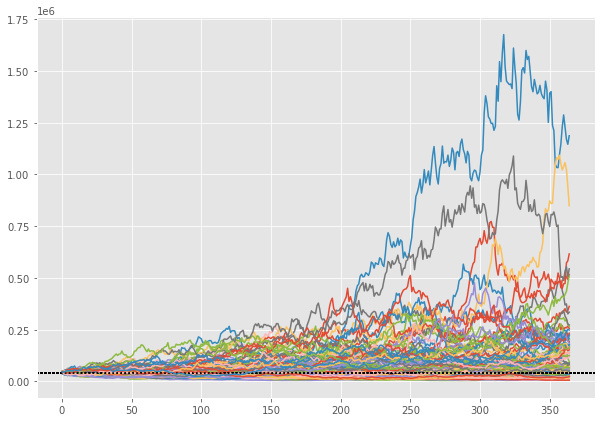

In [30]:
f, ax = plt.subplots(figsize=(10,7)) 

for i in range(100): #100 simulations 
    sim_rets = np.random.normal(mu, sigma, 365) 
    btc_simulation_365_days_from_now = btc_latest_price * (sim_rets + 1).cumprod()
    plt.axhline(btc_latest_price, color='black', linestyle='dotted')
    ax.plot(btc_simulation_365_days_from_now)